In [2]:
#Unsupervised - Correlation Test
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
# File paths
files = [
    "datasets/raw/merged/ncr_ride_bookings_with_weather_filled_scaled_v20.csv",
    "datasets/raw/merged/ncr_ride_bookings_with_weather_filled_scaled_v21.csv",
    "datasets/raw/merged/ncr_ride_bookings_with_weather_filled_scaled_v22.csv",
    "datasets/raw/merged/ncr_ride_bookings_with_weather_filled_scaled_v23.csv"
]

# Read and concatenate
df_list = [pd.read_csv(f) for f in files]
df_merged = pd.concat(df_list, ignore_index=True)

# Optional: remove duplicates if needed
df_merged = df_merged.drop_duplicates()

print(f"Final shape: {df_merged.shape}")
df_merged.head()


Final shape: (145982, 111)


,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,snowfall_pickup_log,precipitation_drop_log,rain_drop_log,snowfall_drop_log,precipitation_pickup_log_scaled,rain_pickup_log_scaled,snowfall_pickup_log_scaled,precipitation_drop_log_scaled,rain_drop_log_scaled,snowfall_drop_log_scaled
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,...,0.0,0.0,0.0,0.0,0.182322,0.182322,0.0,0.0,0.0,0.0
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0


In [19]:
df_merged.shape
# Check all column
columns = df_merged.columns.tolist()
columns

['Date',
 'Time',
 'Booking ID',
 'Booking Status',
 'Customer ID',
 'Vehicle Type',
 'Pickup Location',
 'Drop Location',
 'Avg VTAT',
 'Avg CTAT',
 'Cancelled Rides by Customer',
 'Reason for cancelling by Customer',
 'Cancelled Rides by Driver',
 'Driver Cancellation Reason',
 'Incomplete Rides',
 'Incomplete Rides Reason',
 'Booking Value',
 'Ride Distance',
 'Driver Ratings',
 'Customer Rating',
 'Payment Method',
 'pick_longitude',
 'pick_latitude',
 'pick_address',
 'pick_region',
 'pick_locality',
 'drop_longitude',
 'drop_latitude',
 'drop_address',
 'drop_region',
 'drop_locality',
 'datetime',
 'date',
 'hour',
 'time_pickup',
 'address_x',
 'temperature_2m_pickup',
 'relative_humidity_2m_pickup',
 'dew_point_2m_pickup',
 'apparent_temperature_pickup',
 'precipitation_pickup',
 'rain_pickup',
 'snowfall_pickup',
 'wind_speed_10m_pickup',
 'time_drop',
 'address_y',
 'temperature_2m_drop',
 'relative_humidity_2m_drop',
 'dew_point_2m_drop',
 'apparent_temperature_drop',
 'pre

In [21]:
#Columns to keep

columns = [#'pick_region',
#'Date',
'hour',
'temperature_2m_pickup',
'relative_humidity_2m_pickup',
'dew_point_2m_pickup',
'apparent_temperature_pickup',
'precipitation_pickup',
'rain_pickup',
'snowfall_pickup',
'wind_speed_10m_pickup',
'AvgVTAT_missing_flag',
'AvgCTAT_missing_flag',
'BookingValue_missing_flag',
'RideDistance_missing_flag',
'DriverRatings_missing_flag',
'CustomerRating_missing_flag',
'Avg VTAT_fill',
'Avg CTAT_fill',
'Booking Value_fill',
'Ride Distance_fill',
'Driver Ratings_fill',
'Customer Rating_fill']

In [22]:
df_num = df_merged[columns]

corr_matrix = df_num.corr()

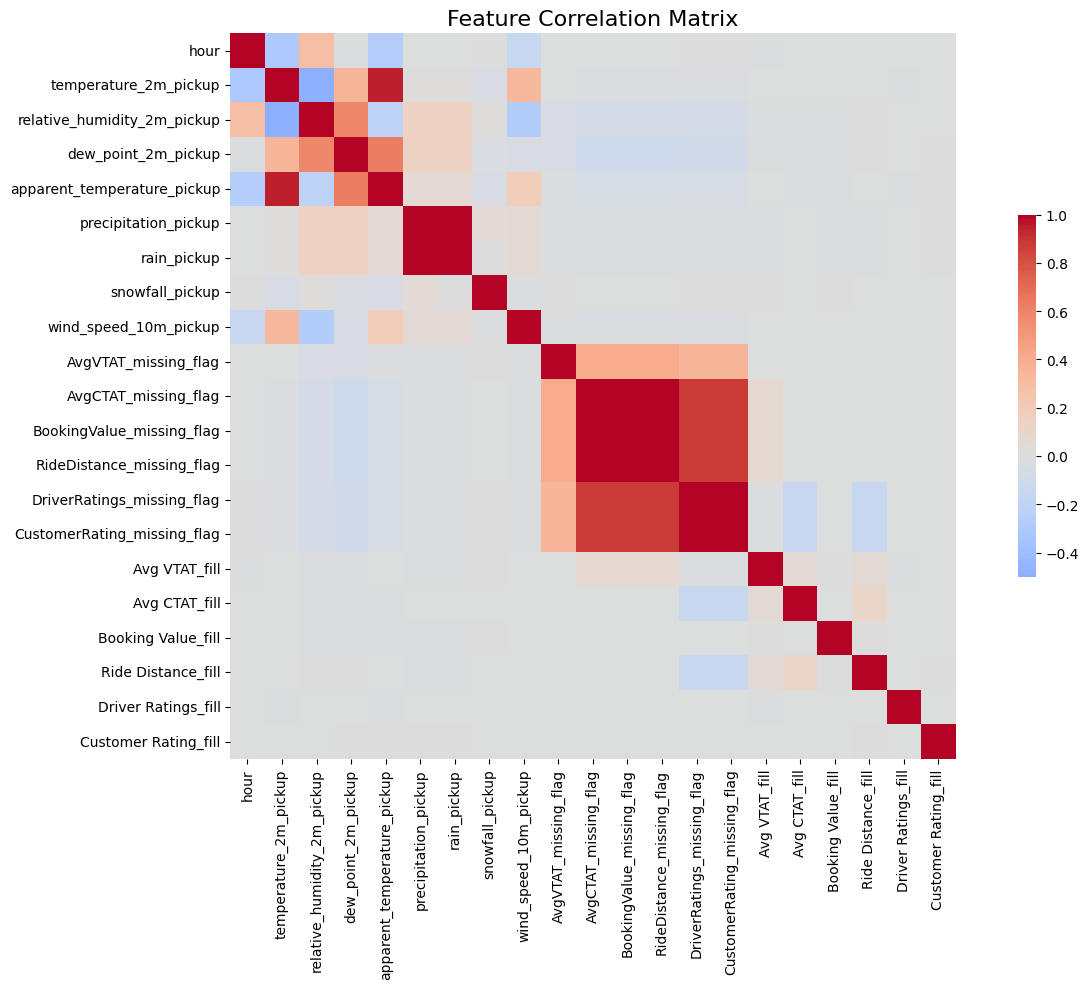

In [23]:
#Graph Correlation Matrix

plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    center=0,
    square=True,
    cbar_kws={'shrink': 0.5}
)
plt.title("Feature Correlation Matrix", fontsize=16)
plt.tight_layout()
plt.show()

In [24]:
cols_to_keep = [
    'Booking ID', 'Customer ID',#join key
    "Vehicle Type",
    "hour",
    "temperature_2m_pickup",        # keep this instead of apparent_temperature_pickup
    "relative_humidity_2m_pickup",
    "dew_point_2m_pickup",
    # "apparent_temperature_pickup"  # dropped because strongly correlated with temperature
    "precipitation_pickup",         # keep this instead of rain_pickup
    # "rain_pickup",                # dropped (duplicate)
    "snowfall_pickup",
    "wind_speed_10m_pickup",
    
    "AvgVTAT_missing_flag",         # keep one representative of missing flag set
    # "AvgCTAT_missing_flag",       # dropped (duplicate with BookingValue_missing_flag)
    # "BookingValue_missing_flag",  # dropped (duplicate with AvgCTAT_missing_flag)
    # "RideDistance_missing_flag",  # dropped (duplicate with BookingValue_missing_flag)
    "DriverRatings_missing_flag",   # keep one
    # "CustomerRating_missing_flag", # dropped (duplicate)
    
    "Avg VTAT_fill",
    "Avg CTAT_fill",
    "Booking Value_fill",
    "Ride Distance_fill",
    "Driver Ratings_fill",
    "Customer Rating_fill"
]

In [27]:
df_final = df_merged[cols_to_keep]
df_final.head()

,Booking ID,Customer ID,Vehicle Type,hour,temperature_2m_pickup,relative_humidity_2m_pickup,dew_point_2m_pickup,precipitation_pickup,snowfall_pickup,wind_speed_10m_pickup,AvgVTAT_missing_flag,DriverRatings_missing_flag,Avg VTAT_fill,Avg CTAT_fill,Booking Value_fill,Ride Distance_fill,Driver Ratings_fill,Customer Rating_fill
0,"""CNR5884300""","""CID1982111""",eBike,12,31.8,24.0,8.9,0.0,0.0,16.6,1,1,8.489832,29.148323,503.256008,24.991943,4.224941,4.404470
1,"""CNR1326809""","""CID4604802""",Go Sedan,18,19.1,51.0,8.6,0.0,0.0,7.3,0,1,4.900000,14.000000,237.000000,5.730000,4.232220,4.408785
2,"""CNR8494506""","""CID9202816""",Auto,8,30.8,75.0,25.8,0.2,0.0,7.6,0,0,13.400000,25.800000,627.000000,13.580000,4.900000,4.900000
3,"""CNR8906825""","""CID2610914""",Premier Sedan,17,24.8,96.0,24.1,0.0,0.0,4.0,0,0,13.100000,28.500000,416.000000,34.020000,4.600000,5.000000
4,"""CNR1950162""","""CID9933542""",Bike,22,24.6,93.0,23.4,0.0,0.0,10.9,0,0,5.300000,19.600000,737.000000,48.210000,4.100000,4.300000


In [ ]:
#df_final.to_csv("datasets/raw/merged/unsupervised_modelling_validation_v2.csv", index=False)